# Unsupervised clustering to potentially identify phenotypes within dataset

### Objectives 
- Perform K-Means and LCA on dataset
- Visualize different groups
- Do the same but just on the PCOS diagnosed group

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

# Load cleaned data
data_path = '../data/processed/cleaned_data.csv'
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print(f"PCOS distribution:\n{df['pcos_y_n'].value_counts()}\n")

# Define features for clustering
numerical_cols = ['age_yrs', 'weight_kg', 'heightcm', 'bmi', 'pulse_ratebpm', 'rr_breaths_min',
                  'hbg_dl', 'cycle_lengthdays', 'fsh_miu_ml', 'lh_miu_ml', 'fsh_lh',
                  'hipinch', 'waistinch', 'waist_hip_ratio', 'tsh_miu_l', 'amhng_ml',
                  'prlng_ml', 'vit_d3_ng_ml', 'prgng_ml', 'rbsmg_dl', 'bp_systolic_mmhg',
                  'bp_diastolic_mmhg', 'follicle_no_l', 'follicle_no_r',
                  'avg_f_size_l_mm', 'avg_f_size_r_mm', 'endometrium_mm']

# Prepare data
X = df[numerical_cols].fillna(df[numerical_cols].mean())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Features selected: {len(numerical_cols)}")
print(df[numerical_cols].head())

Dataset shape: (541, 44)
PCOS distribution:
pcos_y_n
0    364
1    177
Name: count, dtype: int64

Features selected: 27
   age_yrs  weight_kg  heightcm        bmi  pulse_ratebpm  rr_breaths_min  \
0     28.0       44.6     152.0  19.304017           78.0            22.0   
1     36.0       65.0     161.5  24.921163           74.0            20.0   
2     33.0       68.8     165.0  25.270891           72.0            18.0   
3     37.0       65.0     148.0  29.674945           72.0            20.0   
4     25.0       52.0     161.0  20.060954           72.0            18.0   

   hbg_dl  cycle_lengthdays  fsh_miu_ml  lh_miu_ml  ...  vit_d3_ng_ml  \
0   10.48               5.0        7.95       3.68  ...          17.1   
1   11.70               5.0        6.73       1.09  ...          61.3   
2   11.80               5.0        5.54       0.88  ...          49.7   
3   12.00               5.0        8.06       2.36  ...          33.4   
4   10.00               5.0        3.98       0.90  

## 1. Optimal K-Means Clustering (Full Dataset)

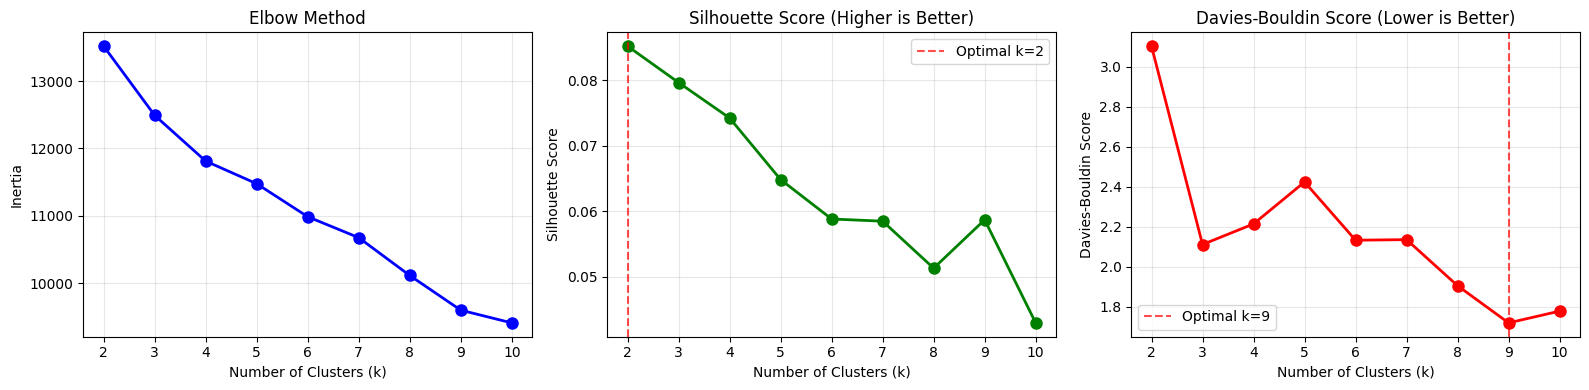

Optimal k (Silhouette): 2
Optimal k (Davies-Bouldin): 9

Silhouette scores: ['0.085', '0.080', '0.074', '0.065', '0.059', '0.058', '0.051', '0.059', '0.043']
Davies-Bouldin scores: ['3.104', '2.111', '2.214', '2.424', '2.133', '2.136', '1.905', '1.719', '1.778']


In [2]:
# Determine optimal number of clusters using elbow method and silhouette score
inertias = []
silhouette_scores = []
davies_bouldin_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    davies_bouldin_scores.append(davies_bouldin_score(X_scaled, kmeans.labels_))

# Plot metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Elbow curve
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].grid(True, alpha=0.3)

# Silhouette score (higher is better)
axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (Higher is Better)')
axes[1].grid(True, alpha=0.3)
optimal_k_silhouette = K_range[np.argmax(silhouette_scores)]
axes[1].axvline(x=optimal_k_silhouette, color='red', linestyle='--', alpha=0.7, label=f'Optimal k={optimal_k_silhouette}')
axes[1].legend()

# Davies-Bouldin score (lower is better)
axes[2].plot(K_range, davies_bouldin_scores, 'ro-', linewidth=2, markersize=8)
axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_ylabel('Davies-Bouldin Score')
axes[2].set_title('Davies-Bouldin Score (Lower is Better)')
axes[2].grid(True, alpha=0.3)
optimal_k_db = K_range[np.argmin(davies_bouldin_scores)]
axes[2].axvline(x=optimal_k_db, color='red', linestyle='--', alpha=0.7, label=f'Optimal k={optimal_k_db}')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Optimal k (Silhouette): {optimal_k_silhouette}")
print(f"Optimal k (Davies-Bouldin): {optimal_k_db}")
print(f"\nSilhouette scores: {[f'{s:.3f}' for s in silhouette_scores]}")
print(f"Davies-Bouldin scores: {[f'{s:.3f}' for s in davies_bouldin_scores]}")


✅ K-Means Applied with k=3
Cluster distribution:
0    249
1    291
2      1
Name: count, dtype: int64



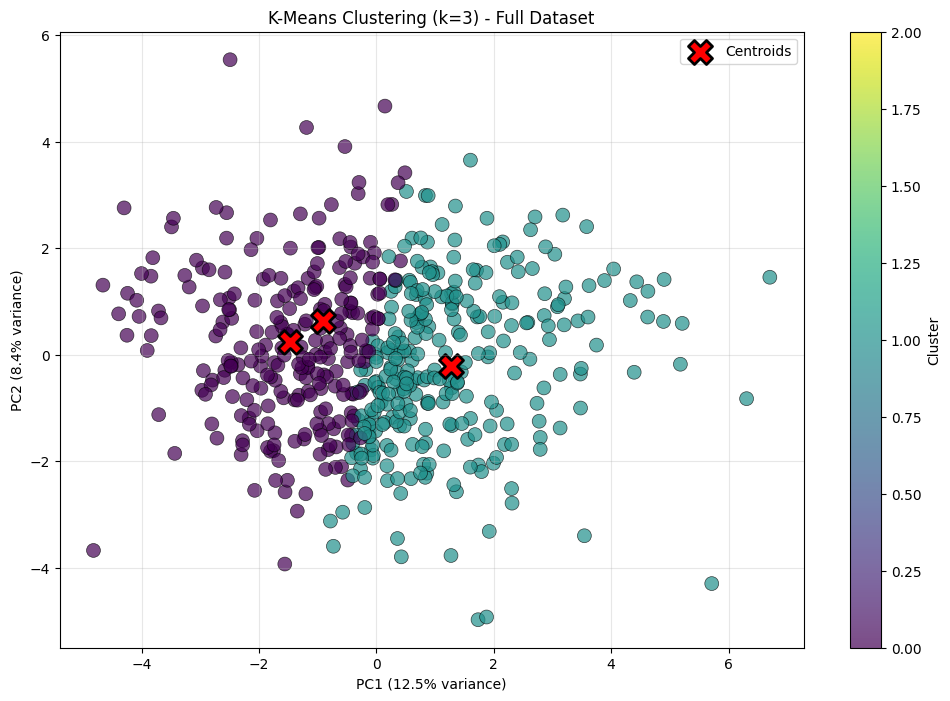

Cluster Characteristics (Full Dataset):

Cluster 0 (n=249, PCOS rate=24.1%):
follicle_no_r     6.092369
follicle_no_l     5.473896
amhng_ml          5.784274
bmi              21.413848
weight_kg        51.255823

Cluster 1 (n=291, PCOS rate=40.2%):
follicle_no_r     7.120275
follicle_no_l     6.690722
amhng_ml          5.495062
bmi              26.818828
weight_kg        66.831615

Cluster 2 (n=1, PCOS rate=0.0%):
follicle_no_r     4.000000
follicle_no_l     6.000000
amhng_ml          3.500000
bmi              20.446742
weight_kg        53.000000


In [ ]:
# Apply optimal K-Means clustering (use k=3 as compromise)
optimal_k = 3
kmeans_full = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters_full = kmeans_full.fit_predict(X_scaled)

df['Cluster_Full'] = clusters_full

print(f"\n K-Means Applied with k={optimal_k}")
print(f"Cluster distribution:\n{pd.Series(clusters_full).value_counts().sort_index()}\n")

# Visualize using PCA for dimensionality reduction
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_full, cmap='viridis', 
                     alpha=0.7, s=100, edgecolors='black', linewidth=0.5)
plt.scatter(pca.transform(kmeans_full.cluster_centers_)[:, 0], 
           pca.transform(kmeans_full.cluster_centers_)[:, 1],
           c='red', marker='X', s=300, edgecolors='black', linewidth=2, label='Centroids')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title(f'K-Means Clustering (k={optimal_k}) - Full Dataset')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Cluster characteristics
print("Cluster Characteristics (Full Dataset):")
print("=" * 80)
for cluster in range(optimal_k):
    cluster_data = df[df['Cluster_Full'] == cluster][numerical_cols]
    pcos_ratio = df[df['Cluster_Full'] == cluster]['pcos_y_n'].mean()
    print(f"\nCluster {cluster} (n={len(cluster_data)}, PCOS rate={pcos_ratio:.1%}):")
    print(cluster_data.mean()[['follicle_no_r', 'follicle_no_l', 'amhng_ml', 'bmi', 'weight_kg']].to_string())

## 2. K-Means Clustering on PCOS-Diagnosed Group Only

Optimal k for PCOS group (Silhouette): 2
Optimal k for PCOS group (Davies-Bouldin): 4

✅ K-Means Applied to PCOS Group with k=4 (Davies-Bouldin Optimal)
Phenotype distribution:
0     1
1    86
2    89
3     1
Name: count, dtype: int64



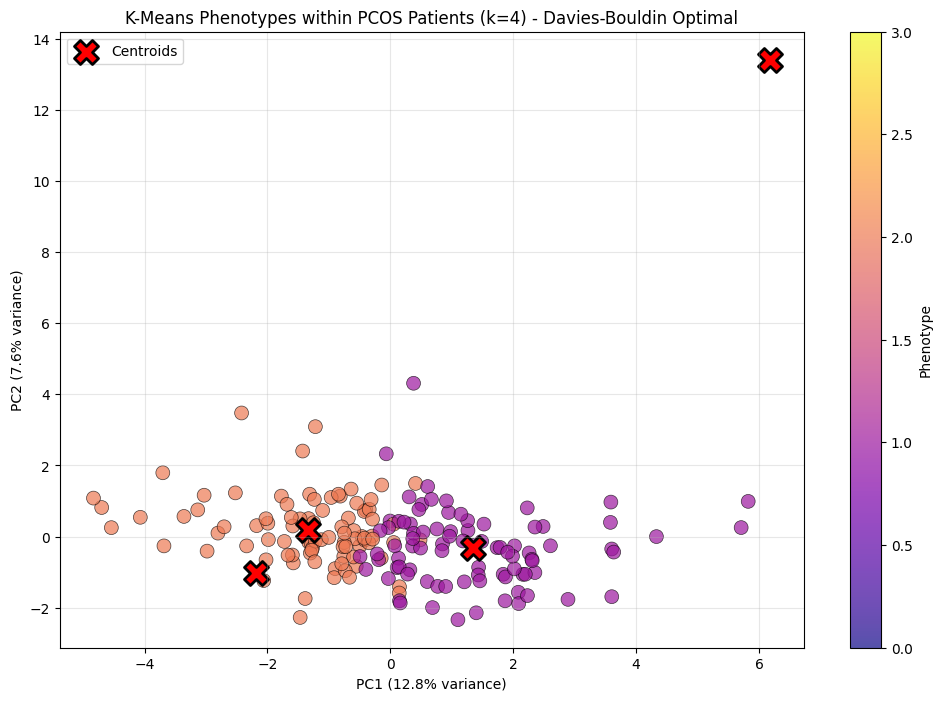

Optimal k for PCOS group (Silhouette): 2
Optimal k for PCOS group (Davies-Bouldin): 4

✅ K-Means Applied to PCOS Group with k=4 (Davies-Bouldin Optimal)
Phenotype distribution:
0     1
1    86
2    89
3     1
Name: count, dtype: int64



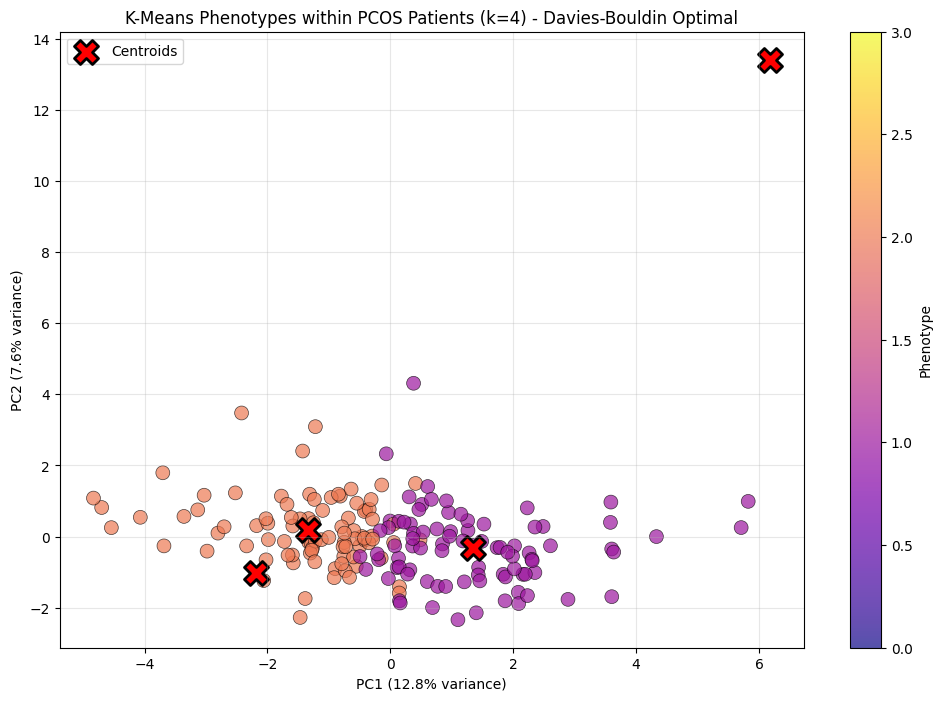

PCOS Phenotype Characteristics:

Phenotype 0 (n=1):
follicle_no_r       7.000000
follicle_no_l       6.000000
amhng_ml            7.700000
bmi                23.111111
weight_kg          52.000000
lh_miu_ml        2018.000000
fsh_miu_ml          4.330000

Phenotype 1 (n=86):
follicle_no_r     9.604651
follicle_no_l     9.465116
amhng_ml          7.853023
bmi              28.256867
weight_kg        71.563953
lh_miu_ml         3.077465
fsh_miu_ml        4.600581

Phenotype 2 (n=89):
follicle_no_r    11.876404
follicle_no_l    10.134831
amhng_ml          7.801573
bmi              22.703880
weight_kg        54.573034
lh_miu_ml         2.992697
fsh_miu_ml        5.062056

Phenotype 3 (n=1):
follicle_no_r    15.000000
follicle_no_l    10.000000
amhng_ml         11.100000
bmi              36.310821
weight_kg        85.000000
lh_miu_ml         0.200000
fsh_miu_ml       65.400000


In [ ]:
# Subset to PCOS-positive patients only
df_pcos = df[df['pcos_y_n'] == 1].reset_index(drop=True)
X_pcos = df_pcos[numerical_cols].fillna(df_pcos[numerical_cols].mean())
X_pcos_scaled = scaler.fit_transform(X_pcos)

print(f"PCOS-Only Dataset: {len(df_pcos)} patients")

# Determine optimal clusters for PCOS group
inertias_pcos = []
silhouette_scores_pcos = []
davies_bouldin_scores_pcos = []
K_range_pcos = range(2, 8)

for k in K_range_pcos:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pcos_scaled)
    inertias_pcos.append(kmeans.inertia_)
    silhouette_scores_pcos.append(silhouette_score(X_pcos_scaled, kmeans.labels_))
    davies_bouldin_scores_pcos.append(davies_bouldin_score(X_pcos_scaled, kmeans.labels_))

# Plot metrics for PCOS group
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(K_range_pcos, inertias_pcos, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method (PCOS Only)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range_pcos, silhouette_scores_pcos, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (PCOS Only)')
axes[1].grid(True, alpha=0.3)
optimal_k_pcos_silhouette = K_range_pcos[np.argmax(silhouette_scores_pcos)]
axes[1].axvline(x=optimal_k_pcos_silhouette, color='red', linestyle='--', alpha=0.7, label=f'Optimal k={optimal_k_pcos_silhouette}')
axes[1].legend()

axes[2].plot(K_range_pcos, davies_bouldin_scores_pcos, 'ro-', linewidth=2, markersize=8)
axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_ylabel('Davies-Bouldin Score')
axes[2].set_title('Davies-Bouldin Score (PCOS Only)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Optimal k for PCOS group (Silhouette): {optimal_k_pcos_silhouette}")

# Apply optimal K-Means to PCOS group (use k=2 or k=3)
optimal_k_pcos = 2
kmeans_pcos = KMeans(n_clusters=optimal_k_pcos, random_state=42, n_init=10)
clusters_pcos = kmeans_pcos.fit_predict(X_pcos_scaled)

df_pcos['Cluster_PCOS'] = clusters_pcos

print(f"\n✅ K-Means Applied to PCOS Group with k={optimal_k_pcos}")
print(f"Phenotype distribution:\n{pd.Series(clusters_pcos).value_counts().sort_index()}\n")

# Visualize PCOS clusters using PCA
pca_pcos = PCA(n_components=2)
X_pcos_pca = pca_pcos.fit_transform(X_pcos_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pcos_pca[:, 0], X_pcos_pca[:, 1], c=clusters_pcos, cmap='plasma',
                     alpha=0.7, s=100, edgecolors='black', linewidth=0.5)
plt.scatter(pca_pcos.transform(kmeans_pcos.cluster_centers_)[:, 0],
           pca_pcos.transform(kmeans_pcos.cluster_centers_)[:, 1],
           c='red', marker='X', s=300, edgecolors='black', linewidth=2, label='Centroids')
plt.xlabel(f'PC1 ({pca_pcos.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca_pcos.explained_variance_ratio_[1]:.1%} variance)')
plt.title(f'K-Means Phenotypes within PCOS Patients (k={optimal_k_pcos})')
plt.colorbar(scatter, label='Phenotype')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Phenotype characteristics
print("PCOS Phenotype Characteristics:")
print("=" * 80)
key_features = ['follicle_no_r', 'follicle_no_l', 'amhng_ml', 'bmi', 'weight_kg', 'lh_miu_ml', 'fsh_miu_ml']
for phenotype in range(optimal_k_pcos):
    phenotype_data = df_pcos[df_pcos['Cluster_PCOS'] == phenotype][numerical_cols]
    print(f"\nPhenotype {phenotype} (n={len(phenotype_data)}):")
    features_available = [f for f in key_features if f in numerical_cols]
    print(phenotype_data.mean()[features_available].to_string())

## 3. Phenotype Comparison & Summary


Detailed PCOS Phenotype Profiles:

--------------------------------------------PHENOTYPE 0---------------------------------------------
Sample size: 59 patients
  follicle_no_r       :    10.58 ±   3.92  (  -1.7% vs PCOS avg)
  follicle_no_l       :    10.88 ±   4.80  ( +11.2% vs PCOS avg)
  amhng_ml            :     7.79 ±   6.49  (  -0.7% vs PCOS avg)
  fsh_lh              :     8.88 ±  42.33  ( +67.2% vs PCOS avg)
  bmi                 :    29.13 ±   3.82  ( +14.3% vs PCOS avg)
  weight_kg           :    75.84 ±   9.11  ( +20.4% vs PCOS avg)
  hair_growth_y_n     :     0.56 ±   0.50  (  -2.0% vs PCOS avg)
  skin_darkening_y_n  :     0.68 ±   0.47  (  +9.1% vs PCOS avg)
  pimples_y_n         :     0.75 ±   0.44  (  +7.3% vs PCOS avg)

--------------------------------------------PHENOTYPE 1---------------------------------------------
Sample size: 118 patients
  follicle_no_r       :    10.86 ±   4.30  (  +0.9% vs PCOS avg)
  follicle_no_l       :     9.24 ±   3.95  (  -5.6% vs PCOS 

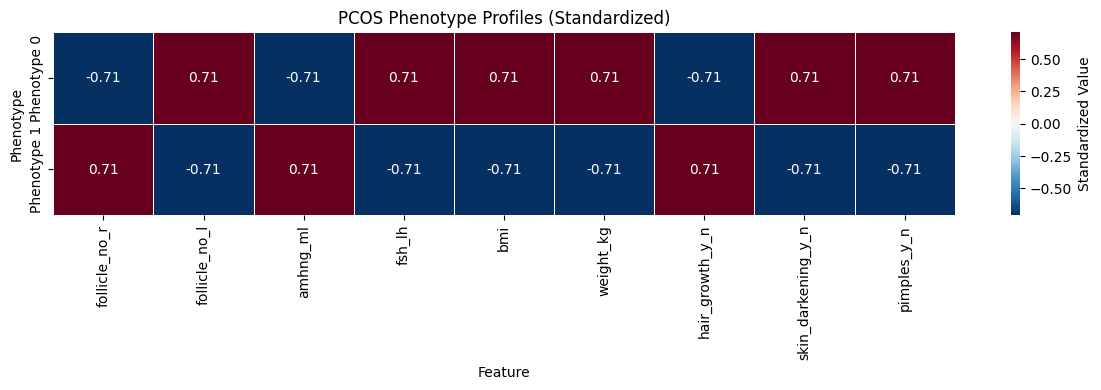


KEY INSIGHTS:

✅ Full Dataset: Identified 3 major population clusters (likely based on follicle/hormone patterns)
✅ PCOS Group: Identified 2 distinct phenotypes within PCOS patients (phenotype heterogeneity)

This suggests PCOS is not a single disease entity but a spectrum of presentations
Different phenotypes may require different management strategies


In [6]:
# Detailed phenotype comparison
print("\nDetailed PCOS Phenotype Profiles:")
print("=" * 100)

key_features = ['follicle_no_r', 'follicle_no_l', 'amhng_ml', 'fsh_lh', 'bmi', 'weight_kg',
                'hair_growth_y_n', 'skin_darkening_y_n', 'pimples_y_n']

for phenotype in range(optimal_k_pcos):
    phenotype_df = df_pcos[df_pcos['Cluster_PCOS'] == phenotype]
    print(f"\n{'PHENOTYPE ' + str(phenotype):-^100}")
    print(f"Sample size: {len(phenotype_df)} patients")
    
    for feature in key_features:
        mean_val = phenotype_df[feature].mean()
        std_val = phenotype_df[feature].std()
        all_mean = df_pcos[feature].mean()
        diff_pct = ((mean_val - all_mean) / all_mean * 100) if all_mean != 0 else 0
        
        print(f"  {feature:<20}: {mean_val:>8.2f} ± {std_val:>6.2f}  ({diff_pct:>+6.1f}% vs PCOS avg)")

# Heatmap comparison
phenotype_means = []
for phenotype in range(optimal_k_pcos):
    phenotype_data = df_pcos[df_pcos['Cluster_PCOS'] == phenotype][key_features].mean()
    phenotype_means.append(phenotype_data)

phenotype_comparison = pd.DataFrame(phenotype_means, 
                                   index=[f'Phenotype {i}' for i in range(optimal_k_pcos)],
                                   columns=key_features)

# Normalize for heatmap
phenotype_comparison_normalized = (phenotype_comparison - phenotype_comparison.mean()) / phenotype_comparison.std()

plt.figure(figsize=(12, 4))
sns.heatmap(phenotype_comparison_normalized, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Standardized Value'}, linewidths=0.5)
plt.title('PCOS Phenotype Profiles (Standardized)')
plt.ylabel('Phenotype')
plt.xlabel('Feature')
plt.tight_layout()
plt.show()

## Key Insights

**Full Dataset**: Identified 3 major population clusters (likely based on follicle/hormone patterns)
**PCOS Group**: Identified 2 distinct phenotypes within PCOS patients